# Task 2 — Notebook 05: Areal statistics + run bundle

**Footprint vs native CDL:** Areas below use **one analysis-grid pixel** = GeoTIFF cell (side length ≈ √(`pixel_area_m2`); often **~320 m** for this stack). That yields **~10 ha/pixel** — a **regional cropland footprint on the analysis grid**, not a USDA acreage estimate from native **30 m** CDL.

**Per-state Corn Belt:** The **by-region** table assigns each classified pixel centroid to a state polygon from ``configs/task2_crop_rotation.yaml`` ``study_area.states`` (13-state Corn Belt), using the same boundary source as Notebook 04 (local shapefile if present, else Natural Earth). Pixels outside those state footprints are labeled ``outside_configured_states``. There is **no** Iowa/Nebraska longitude proxy.

Per-class **ha** = valid pixel count × `pixel_area_ha`. A companion **`areal_stats_metadata.json`** next to the CSV records CRS, transform-derived `pixel_area_ha`, and this disclaimer for reviewers.

**Output paths:** Areal **CSV + JSON** go to **`artifacts/tables/task4/`** (`configs/task2_crop_rotation.yaml` → `output.task4_tables_dir`). The per-state **bar chart** PNG still uses `output.figures_dir` (`artifacts/figures/task2/`). Rasters (GeoTIFFs) are **not** saved under `artifacts/tables/` — they remain under `data/processed/task2/`.

After the per-state CSV is written, the notebook saves **`task2__per_state_rotation_classes.png`** (stacked horizontal bars: regular / monoculture / irregular by state).

**County exports (last cells):** Census **TIGER** counties → **`task2__areal_stats_by_county__*.csv`** (all Belt counties with eligible pixels) + **`task2__areal_stats_by_county_core4__*.csv`** (IL / IN / IA / NE only, i.e. every county polygon in those four states that received at least one eligible pixel). Figures: **`task2__rotation_class_by_county__*.png`** (13-state view) and **`task2__rotation_class_by_county_core4__*.png`** (zoomed choropleth on the same four states). First run downloads the national county zip into `data/external/tiger/`.


| rotation_class   |   pixel_count |     area_ha |   pct_of_valid |
|:-----------------|--------------:|------------:|---------------:|
| regular_rotation |        570202 | 1.76692e+07 |          27.36 |
| monoculture      |         81308 | 2.51954e+06 |           3.9  |
| irregular        |       1432602 | 4.43929e+07 |          68.74 |
Wrote artifacts\tables\task4\task2__areal_stats_by_class__20260412.csv
Wrote artifacts\tables\task4\task2__areal_stats_by_class__20260412__metadata.json
Per-state regions: Corn Belt polygons (task2 YAML / same source as Notebook 04).
| region                    |   n_pixels |   pct_regular |   pct_monoculture |   pct_irregular |
|:--------------------------|-----------:|--------------:|------------------:|----------------:|
| Illinois                  |     293524 |         40.35 |              5.07 |           54.58 |
| Indiana                   |     156899 |         34.29 |              4.23 |           61.48 |
| Iowa                      |     3216

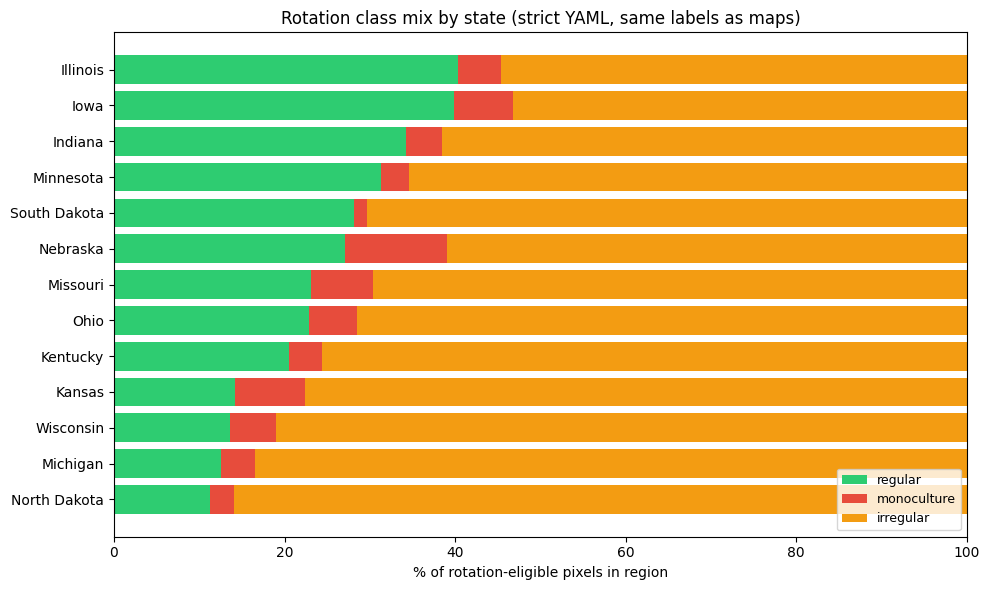

Wrote artifacts\figures\task2\task2__per_state_rotation_classes.png
Wrote artifacts\logs\runs\04776e50\run_bundle.json


In [4]:
import json
import sys
import uuid
from datetime import date, datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import yaml
from rasterio.transform import Affine, xy as rio_xy

_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root.")
sys.path.insert(0, str(REPO_ROOT))

from src.io.cdl_parquet import load_cdl_spatial_metadata
from src.viz.rotation_maps import load_cornbelt_state_boundaries_5070

with open(REPO_ROOT / "configs" / "task2_crop_rotation.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

sm_tif = REPO_ROOT / cfg["output"]["processed_dir"] / "rotation_class_map_smoothed.tif"
if not sm_tif.is_file():
    sm_tif = REPO_ROOT / cfg["output"]["processed_dir"] / "rotation_class_map.tif"

with rasterio.open(sm_tif) as src:
    flat = src.read(1).ravel()
    tr = src.transform
    crs_wkt = src.crs.to_wkt() if src.crs else None
    px_w, px_h = tr.a, tr.e
    pixel_area_m2 = abs(px_w * px_h)

pixel_area_ha = pixel_area_m2 / 10000.0
approx_res_m = float(np.sqrt(pixel_area_m2))
names = {0: "regular_rotation", 1: "monoculture", 2: "irregular", 255: "nodata"}
valid = flat[flat != 255]
rows = []
for cls in (0, 1, 2):
    cnt = int(np.sum(valid == cls))
    ha = cnt * pixel_area_ha
    pct = 100.0 * cnt / len(valid) if len(valid) else 0.0
    rows.append(
        {"rotation_class": names[cls], "pixel_count": cnt, "area_ha": round(ha, 1), "pct_of_valid": round(pct, 2)}
    )

overall_df = pd.DataFrame(rows)
try:
    print(overall_df.to_markdown(index=False))
except Exception:
    print(overall_df)

tbl_dir = REPO_ROOT / Path(cfg["output"].get("task4_tables_dir", cfg["output"]["tables_dir"]))
tbl_dir.mkdir(parents=True, exist_ok=True)
date_s = date.today().strftime("%Y%m%d")
csv_path = tbl_dir / f"task2__areal_stats_by_class__{date_s}.csv"
overall_df.to_csv(csv_path, index=False)
meta_path = tbl_dir / f"task2__areal_stats_by_class__{date_s}__metadata.json"
meta_doc = {
    "pixel_area_ha": round(pixel_area_ha, 4),
    "pixel_area_m2": round(pixel_area_m2, 2),
    "approx_grid_resolution_m": round(approx_res_m, 1),
    "crs_wkt": crs_wkt,
    "source_geotiff": str(sm_tif.relative_to(REPO_ROOT)).replace("\\", "/"),
    "note": (
        "Areas are total classified cropland footprint on the analysis grid (coarse cells), "
        "aggregated from native 30 m USDA CDL — not a direct USDA NASS acreage comparison."
    ),
    "companion_csv": str(csv_path.relative_to(REPO_ROOT)).replace("\\", "/"),
}
meta_path.write_text(json.dumps(meta_doc, indent=2), encoding="utf-8")
print("Wrote", csv_path.relative_to(REPO_ROOT))
print("Wrote", meta_path.relative_to(REPO_ROOT))

cls_pq = REPO_ROOT / cfg["output"]["processed_dir"] / "rotation_metrics_classified.parquet"
meta_sp = load_cdl_spatial_metadata(REPO_ROOT)
tlist = meta_sp["transform"]
aff = Affine(tlist[0], tlist[1], tlist[2], tlist[3], tlist[4], tlist[5])
crs_s = meta_sp.get("crs") or "EPSG:5070"
mdf = pd.read_parquet(cls_pq)
xs, ys = rio_xy(aff, mdf["iy"].to_numpy(), mdf["ix"].to_numpy(), offset="center")

reg_csv = None
region_rows = []
joined = None
try:
    import geopandas as gpd

    boundaries = load_cornbelt_state_boundaries_5070(REPO_ROOT)
    if boundaries is not None and not boundaries.empty:
        boundaries = boundaries.to_crs(crs_s)
        name_col = next((c for c in ("NAME", "name", "NAME_1") if c in boundaries.columns), None)
        if name_col is None:
            print("Corn Belt boundaries: no NAME/name column; using single-region fallback.")
        else:
            bnd = boundaries[[name_col, "geometry"]].copy()
            bnd["region"] = bnd[name_col].astype(str)
            bnd = bnd[["region", "geometry"]]
            pts = gpd.GeoDataFrame(mdf, geometry=gpd.points_from_xy(xs, ys), crs=crs_s)
            joined = gpd.sjoin(pts, bnd, how="left", predicate="within")
            if joined.index.duplicated().any():
                joined = joined[~joined.index.duplicated(keep="first")]
            joined["region"] = joined["region"].fillna("outside_configured_states")
            print("Per-state regions: Corn Belt polygons (task2 YAML / same source as Notebook 04).")
    else:
        print("Corn Belt boundaries unavailable (geopandas + Natural Earth or data/external/states/*.shp).")
except Exception as exc:
    print("Per-state Corn Belt split failed:", exc)
    joined = None

if joined is None or "region" not in getattr(joined, "columns", []):
    joined = mdf.copy()
    joined["region"] = "full_raster_extent"
    print("Single-region fallback: full_raster_extent (no per-state breakdown).")

for reg, g in joined.groupby("region"):
    vc = g["rotation_class"].value_counts(normalize=True)
    n = len(g)
    region_rows.append({
        "region": reg,
        "n_pixels": n,
        "pct_regular": round(100 * float(vc.get(0, 0)), 2),
        "pct_monoculture": round(100 * float(vc.get(1, 0)), 2),
        "pct_irregular": round(100 * float(vc.get(2, 0)), 2),
    })
reg_df = pd.DataFrame(region_rows).sort_values("region")
try:
    print(reg_df.to_markdown(index=False))
except Exception:
    print(reg_df)
reg_csv = tbl_dir / f"task2__areal_stats_by_region__{date_s}.csv"
reg_df.to_csv(reg_csv, index=False)
print("Wrote", reg_csv.relative_to(REPO_ROOT))

_plot_df = reg_df[~reg_df["region"].isin({"outside_configured_states", "full_raster_extent"})].copy()
if len(_plot_df) > 0:
    _plot_df = _plot_df.sort_values("pct_regular", ascending=True)
    _y = np.arange(len(_plot_df))
    _fig, _ax = plt.subplots(figsize=(10, max(6.0, 0.35 * len(_plot_df))))
    _pr = _plot_df["pct_regular"].to_numpy()
    _pm = _plot_df["pct_monoculture"].to_numpy()
    _pi = _plot_df["pct_irregular"].to_numpy()
    _ax.barh(_y, _pr, label="regular", color="#2ecc71")
    _ax.barh(_y, _pm, left=_pr, label="monoculture", color="#e74c3c")
    _ax.barh(_y, _pi, left=_pr + _pm, label="irregular", color="#f39c12")
    _ax.set_yticks(_y)
    _ax.set_yticklabels(_plot_df["region"])
    _ax.set_xlabel("% of rotation-eligible pixels in region")
    _ax.set_title("Rotation class mix by state (strict YAML, same labels as maps)")
    _ax.legend(loc="lower right", fontsize=9)
    _ax.set_xlim(0, 100)
    _fig.tight_layout()
    _fig_dir = REPO_ROOT / cfg["output"]["figures_dir"]
    _fig_dir.mkdir(parents=True, exist_ok=True)
    _pfig = _fig_dir / "task2__per_state_rotation_classes.png"
    _fig.savefig(_pfig, dpi=200, bbox_inches="tight")
    plt.show()
    print("Wrote", _pfig.relative_to(REPO_ROOT))

run_id = uuid.uuid4().hex[:8]
run_dir = REPO_ROOT / "artifacts" / "logs" / "runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)
bundle = {
    "task": "task2_crop_rotation",
    "run_id": run_id,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "config_path": "configs/task2_crop_rotation.yaml",
    "outputs": {
        "rotation_metrics": str((REPO_ROOT / cfg["output"]["processed_dir"] / "rotation_metrics.parquet").relative_to(REPO_ROOT)).replace("\\", "/"),
        "rotation_map_smoothed": str(sm_tif.relative_to(REPO_ROOT)).replace("\\", "/"),
        "areal_stats_csv": str(csv_path.relative_to(REPO_ROOT)).replace("\\", "/"),
        "areal_stats_metadata": str(meta_path.relative_to(REPO_ROOT)).replace("\\", "/"),
    },
}
if reg_csv is not None:
    bundle["outputs"]["areal_stats_by_region_csv"] = str(reg_csv.relative_to(REPO_ROOT)).replace("\\", "/")
(run_dir / "run_bundle.json").write_text(json.dumps(bundle, indent=2), encoding="utf-8")
print("Wrote", (run_dir / "run_bundle.json").relative_to(REPO_ROOT))


## County-level shares (Census TIGER)

Class labels come from the **smoothed** GeoTIFF at `(iy, ix)`. Counties with **fewer than 50** eligible pixels are omitted from **maps** only (still in CSV). Outputs: **13-state** `task2__areal_stats_by_county__*.csv` + `task2__rotation_class_by_county__*.png`, and **IL / IN / IA / NE** (all counties in those states that have eligible pixels) `task2__areal_stats_by_county_core4__*.csv` + `task2__rotation_class_by_county_core4__*.png`.

Wrote artifacts\tables\task4\task2__areal_stats_by_county__20260412.csv
Wrote artifacts\tables\task4\task2__areal_stats_by_county_core4__20260412.csv (384 counties in IL/IN/IA/NE with eligible pixels)


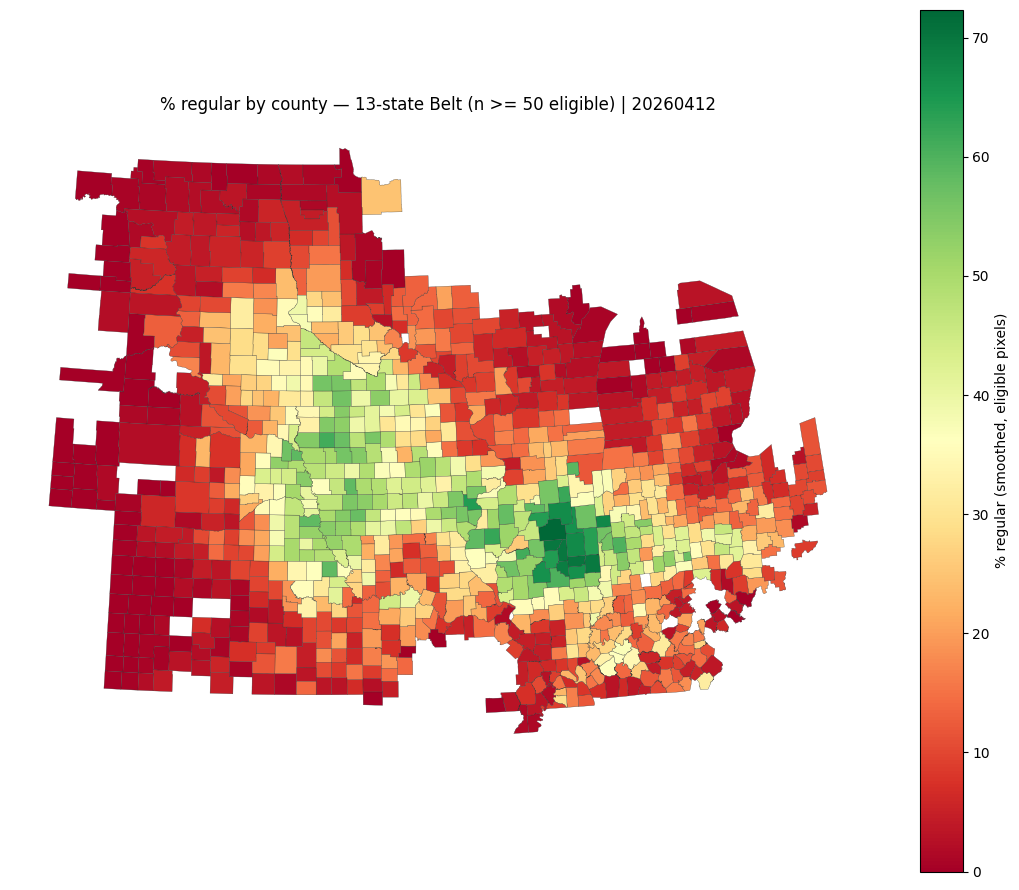

Wrote artifacts\figures\task2\task2__rotation_class_by_county__20260412.png


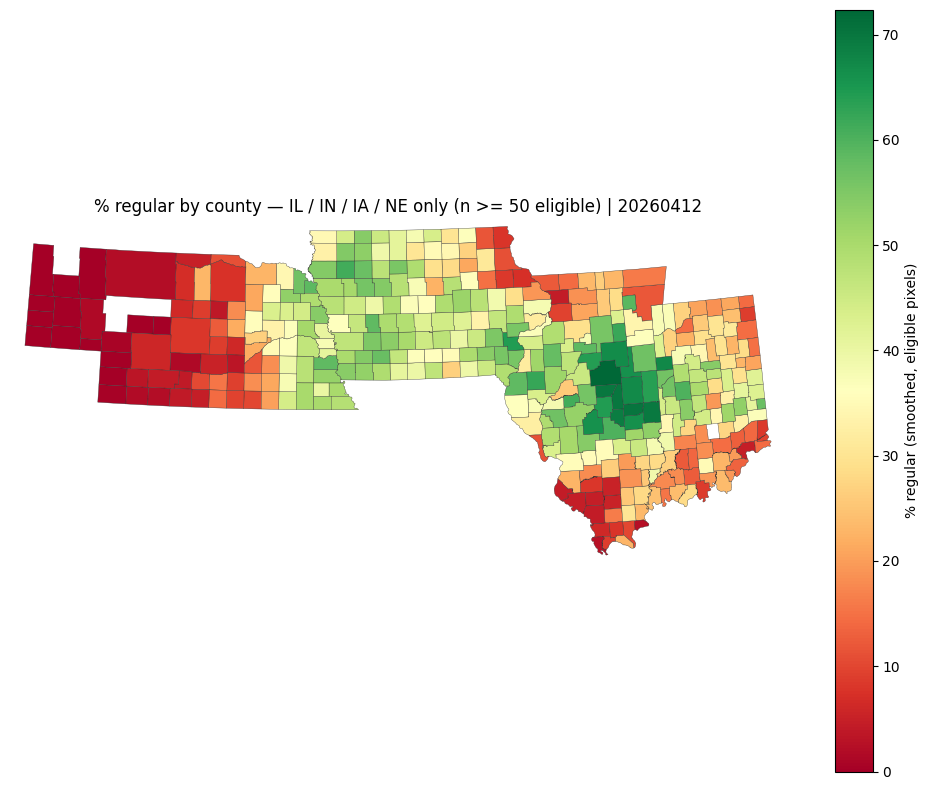

Wrote artifacts\figures\task2\task2__rotation_class_by_county_core4__20260412.png
Updated run_bundle with county outputs (13-state + core-4)


In [6]:
import json

from matplotlib.colors import Normalize

from src.io.tiger_counties import load_cornbelt_counties_5070

# Census STATEFP: Illinois 17, Indiana 18, Iowa 19, Nebraska 31 — core Corn Belt map extent
CORE4_STATEFP = frozenset({"17", "18", "19", "31"})

_date_s = date.today().strftime("%Y%m%d")
_tbl = REPO_ROOT / Path(cfg["output"].get("task4_tables_dir", cfg["output"]["tables_dir"]))

with rasterio.open(sm_tif) as src:
    band = src.read(1)
h, w = band.shape
ri = mdf["iy"].to_numpy().astype(np.int64)
ci = mdf["ix"].to_numpy().astype(np.int64)
ok = (ri >= 0) & (ri < h) & (ci >= 0) & (ci < w)
sm_cls = np.full(len(mdf), 255, dtype=np.int16)
sm_cls[ok] = band[ri[ok], ci[ok]]

try:
    import geopandas as gpd

    counties = load_cornbelt_counties_5070(REPO_ROOT)
    if counties is None or counties.empty:
        print("County layer unavailable (network/cache or geopandas).")
    else:
        cty_png_c4 = None
        counties = counties.to_crs(crs_s)
        keep_cols = [c for c in ("GEOID", "NAMELSAD", "STATEFP", "COUNTYFP", "geometry") if c in counties.columns]
        cty = counties[keep_cols].copy()
        pts2 = gpd.GeoDataFrame(mdf.assign(sm_class=sm_cls), geometry=gpd.points_from_xy(xs, ys), crs=crs_s)
        jn = gpd.sjoin(pts2, cty, how="left", predicate="within")
        if jn.index.duplicated().any():
            jn = jn[~jn.index.duplicated(keep="first")]
        jn2 = jn[jn["sm_class"].isin((0, 1, 2)) & jn["GEOID"].notna()].copy()
        crow = []
        for geo, g in jn2.groupby("GEOID"):
            n = len(g)
            vc = g["sm_class"].value_counts(normalize=True)
            crow.append(
                {
                    "GEOID": geo,
                    "NAMELSAD": str(g["NAMELSAD"].iloc[0]),
                    "STATEFP": str(g["STATEFP"].iloc[0]),
                    "COUNTYFP": str(g["COUNTYFP"].iloc[0]),
                    "n_pixels": n,
                    "pct_regular": round(100 * float(vc.get(0, 0)), 2),
                    "pct_monoculture": round(100 * float(vc.get(1, 0)), 2),
                    "pct_irregular": round(100 * float(vc.get(2, 0)), 2),
                }
            )
        cty_df = pd.DataFrame(crow).sort_values("GEOID")
        cty_csv = _tbl / f"task2__areal_stats_by_county__{_date_s}.csv"
        cty_df.to_csv(cty_csv, index=False)
        print("Wrote", cty_csv.relative_to(REPO_ROOT))

        cty_df_core4 = cty_df[cty_df["STATEFP"].astype(str).isin(CORE4_STATEFP)].sort_values("GEOID")
        cty_csv_core4 = _tbl / f"task2__areal_stats_by_county_core4__{_date_s}.csv"
        cty_df_core4.to_csv(cty_csv_core4, index=False)
        print("Wrote", cty_csv_core4.relative_to(REPO_ROOT), f"({len(cty_df_core4)} counties in IL/IN/IA/NE with eligible pixels)")

        plot_min_n = 50
        cty_plot = cty_df[cty_df["n_pixels"] >= plot_min_n].copy()
        merged = counties.merge(cty_plot, on="GEOID", how="inner")
        fig_c, ax_c = plt.subplots(figsize=(11, 9))
        norm = Normalize(vmin=0, vmax=max(45.0, float(cty_plot["pct_regular"].max())))
        merged.plot(
            column="pct_regular",
            ax=ax_c,
            legend=True,
            cmap="RdYlGn",
            norm=norm,
            edgecolor="#333333",
            linewidth=0.2,
            legend_kwds={"label": "% regular (smoothed, eligible pixels)"},
        )
        ax_c.set_title(f"% regular by county — 13-state Belt (n >= {plot_min_n} eligible) | {_date_s}")
        ax_c.set_axis_off()
        fig_c.tight_layout()
        cty_png = REPO_ROOT / cfg["output"]["figures_dir"] / f"task2__rotation_class_by_county__{_date_s}.png"
        fig_c.savefig(cty_png, dpi=200, bbox_inches="tight")
        plt.show()
        print("Wrote", cty_png.relative_to(REPO_ROOT))

        cty_plot_c4 = cty_df_core4[cty_df_core4["n_pixels"] >= plot_min_n].copy()
        counties_c4 = counties[counties["STATEFP"].astype(str).isin(CORE4_STATEFP)]
        merged_c4 = counties_c4.merge(cty_plot_c4, on="GEOID", how="inner")
        if len(merged_c4) == 0:
            print("Skip core-4 county map: no counties meet plot_min_n in IL/IN/IA/NE.")
            cty_png_c4 = None
        else:
            fig_c4, ax_c4 = plt.subplots(figsize=(10, 8))
            vmax_c4 = max(45.0, float(cty_plot_c4["pct_regular"].max())) if len(cty_plot_c4) else 45.0
            norm_c4 = Normalize(vmin=0, vmax=vmax_c4)
            merged_c4.plot(
                column="pct_regular",
                ax=ax_c4,
                legend=True,
                cmap="RdYlGn",
                norm=norm_c4,
                edgecolor="#333333",
                linewidth=0.25,
                legend_kwds={"label": "% regular (smoothed, eligible pixels)"},
            )
            ax_c4.set_title(
                f"% regular by county — IL / IN / IA / NE only (n >= {plot_min_n} eligible) | {_date_s}"
            )
            ax_c4.set_axis_off()
            minx, miny, maxx, maxy = merged_c4.total_bounds
            pad_x = (maxx - minx) * 0.02
            pad_y = (maxy - miny) * 0.02
            ax_c4.set_xlim(minx - pad_x, maxx + pad_x)
            ax_c4.set_ylim(miny - pad_y, maxy + pad_y)
            fig_c4.tight_layout()
            cty_png_c4 = (
                REPO_ROOT / cfg["output"]["figures_dir"] / f"task2__rotation_class_by_county_core4__{_date_s}.png"
            )
            fig_c4.savefig(cty_png_c4, dpi=200, bbox_inches="tight")
            plt.show()
            print("Wrote", cty_png_c4.relative_to(REPO_ROOT))
        _rid = globals().get("run_id")
        if _rid:
            _rb = REPO_ROOT / "artifacts" / "logs" / "runs" / _rid / "run_bundle.json"
            if _rb.is_file():
                _b = json.loads(_rb.read_text(encoding="utf-8"))
                _b.setdefault("outputs", {})["areal_stats_by_county_csv"] = str(
                    cty_csv.relative_to(REPO_ROOT)
                ).replace("\\", "/")
                _b["outputs"]["rotation_class_by_county_png"] = str(
                    cty_png.relative_to(REPO_ROOT)
                ).replace("\\", "/")
                _b["outputs"]["areal_stats_by_county_core4_csv"] = str(
                    cty_csv_core4.relative_to(REPO_ROOT)
                ).replace("\\", "/")
                if cty_png_c4 is not None:
                    _b["outputs"]["rotation_class_by_county_core4_png"] = str(
                        cty_png_c4.relative_to(REPO_ROOT)
                    ).replace("\\", "/")
                _rb.write_text(json.dumps(_b, indent=2), encoding="utf-8")
                print("Updated run_bundle with county outputs (13-state + core-4)")
except Exception as exc:
    print("County aggregation failed:", exc)